# Big Data y Machine Learning (UBA) 

## Trabajo Práctico 1: Jugando con APIs y WebScraping 

### Reglas de formato y presentación
- El trabajo debe estar debidamente documentado comentado (utilizando #) para que tanto los docentes como sus compañeros puedan comprender el código fácilmente.

- El mismo debe ser completado en este Jupyter Notebook y entregado como tal, es decir en un archivo .ipynb


### Fecha de entrega:
<font color=red>Martes 31 de Marzo a las 13:00 hs</font> 

### Modalidad de entrega
- Al finalizar el trabajo práctico deben hacer un último <i>commit</i> en su repositorio de GitHub llamado “Entrega final del tp”. 
- Asegurense de haber creado una carpeta llamada TP1. Este Jupyter Notebook y el correspondiente al TP1 deben estar dentro de esa carpeta.
- También deben incorporar el link de su repositorio -para que pueda ser clonado y corregido- en su informe final. Nombrar los archivos <i>"UBA_TP1_Grupo_#"</i> donde # es el número de grupo que le fue asignado.
- La última versión en el repositorio es la que será evaluada. Por lo que es importante que: 
    - No envien el correo hasta no haber terminado y estar seguros de que han hecho el <i>commit y push</i> a la versión final que quieren entregar. 
    - No hagan nuevos <i>push</i> despues de haber entregado su versión final. Esto generaría confusión acerca de que versión es la que quieren que se les corrija.
- En resumen, la carpeta del repositorio debe incluir:
    - El codigo
    - Un documento Word (Parte A) donde esten las figuras y una breve descripción de las mismas.
    - El excel con los links webscrappeados (Parte B)
    - Slides para presentar en el sorteo de exposición grupal

### Parte A

#### Ejercicio 1 - Jugando con APIs
Usando la API del Series de Tiempo de la Republica Argentina [link](https://datosgobar.github.io/series-tiempo-ar-api/applications/) , obtener 2 (dos) series de indicadores del **Ministerio de Justicia y Derechos Humanos de la Nación**. En total, dicho Ministerio tiene **575** series anuales y pueden buscar dos series de indicadores de su interés.

In [1]:
# Importamos las librerías necesarias
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
# Para poder visualizar las series del Ministerio de Justicia y DDHH decidimos hacer una exploración mediante
# un filtro de texto de la API

url_busqueda = "https://apis.datos.gob.ar/series/api/search/"
# Buscamos series relacionadas con el sistema penitenciario (Ministerio de Justicia)
params = {
    "q": "penitenciario",
    "limit": 10,
    "format": "json"
} 
resp = requests.get(url_busqueda, params=params)
resultados = resp.json()

# Exploramos los resultados para identificar las series disponibles
for serie in resultados.get("data", []):
    print("ID:", serie["field"]["id"])
    print("Descripción:", serie["field"]["description"])
    print("---")

ID: sneep_gem_spf
Descripción: Mujeres privadas de libertad. Servicio Penitenciario Federal
---
ID: sneep_deh_spf
Descripción: Personas privadas de libertad. Homicidio doloso. Servicio Penitenciario Federal
---
ID: sneep_gev_spf
Descripción: Varones privados de libertad. Servicio Penitenciario Federal
---
ID: sneep_get_spf
Descripción: Personas trans privadas de libertad. Servicio Penitenciario Federal
---
ID: sneep_pto_spf
Descripción: Personas privadas de libertad. Población total. Servicio Penitenciario Federal
---
ID: sneep_re5_spf
Descripción: Personas privadas de libertad. 35 a 44 años. Servicio Penitenciario Federal
---
ID: sneep_dee_spf
Descripción: Personas privadas de libertad. Estupefacientes. Servicio Penitenciario Federal
---
ID: sneep_slp_spf
Descripción: Personas privadas de libertad. Procesados/as. Servicio Penitenciario Federal
---
ID: sneep_re6_spf
Descripción: Personas privadas de libertad. 45 a 54 años. Servicio Penitenciario Federal
---
ID: sneep_re1_spf
Descripció

In [3]:
# Seleccionamos las siguiente series con sus respectivos ID

# Serie 1: ID: sneep_pto_spf
# Descripción: Personas privadas de libertad. Población total. Servicio Penitenciario Federal
# Serie 2: ID: sneep_slp_spf
# Descripción: Personas privadas de libertad. Procesados/as. Servicio Penitenciario Federal

# URL base de la API de Series de Tiempo
url_series = "https://apis.datos.gob.ar/series/api/series/"

# Parámetros con los IDs REALES encontrados en la búsqueda
params = {
    "ids": "sneep_pto_spf,sneep_gem_spf",   # ← IDs corregidos
    "format": "json",
    "collapse": "year",
    "collapse_aggregation": "avg"
}

# Realizamos la solicitud GET a la API
response = requests.get(url_series, params=params)
print("Status:", response.status_code) 

# Parseamos la respuesta en formato JSON
datos = response.json()
print("Claves del JSON:", datos.keys())
print("Primeras filas:", datos["data"][:3])

Status: 200
Claves del JSON: dict_keys(['data', 'count', 'meta', 'params'])
Primeras filas: [['2002-01-01', 9658.0, 949.0], ['2003-01-01', 8952.0, 791.0], ['2004-01-01', 9738.0, 1010.0]]


In [4]:
# Extraemos la parte "data" del JSON — es una lista de listas
data_raw = datos["data"]

# Creamos el DataFrame asignando nombres descriptivos a cada columna
df = pd.DataFrame(data_raw, columns=["fecha", "poblacion_total", "procesados"])

# Convertimos la fecha de texto a formato fecha real de Python
df["fecha"] = pd.to_datetime(df["fecha"])

# Creamos una columna extra: el porcentaje de procesados sobre el total
# Esto es lo analíticamente interesante de tu elección de series
df["pct_procesados"] = (df["procesados"] / df["poblacion_total"] * 100).round(1)

# Mostramos el DataFrame completo
print(f"Período: {df['fecha'].dt.year.min()} — {df['fecha'].dt.year.max()}")
print(f"Años disponibles: {len(df)}")
print()
print(df.to_string(index=False))

Período: 2002 — 2024
Años disponibles: 23

     fecha  poblacion_total  procesados  pct_procesados
2002-01-01           9658.0       949.0             9.8
2003-01-01           8952.0       791.0             8.8
2004-01-01           9738.0      1010.0            10.4
2005-01-01           9625.0      1105.0            11.5
2006-01-01           9380.0      1106.0            11.8
2007-01-01           9024.0      1040.0            11.5
2008-01-01           9149.0       940.0            10.3
2009-01-01           9210.0       817.0             8.9
2010-01-01           9523.0       780.0             8.2
2011-01-01           9644.0       819.0             8.5
2012-01-01           9807.0       790.0             8.1
2013-01-01           9795.0       760.0             7.8
2014-01-01          10465.0       735.0             7.0
2015-01-01          10311.0       726.0             7.0
2016-01-01          11024.0       767.0             7.0
2017-01-01          11861.0       908.0             7.7
2018-

#### Ejercicio 2 - Repaso de Pandas
Realicen una estadistica descriptiva ambas series de indicadores del Ministerio y  presente en una tabla en su reporte. Dicha tabla debe mostrar: numero de observaciones, media, desvío standard, min, p25, mediana, p75 y max. Comente la tabla en **el reporte**.

In [6]:
# .describe() calcula automáticamente las 8 estadísticas pedidas por el TP
estadisticas = df[["poblacion_total", "procesados", "pct_procesados"]].describe()
estadisticas


,poblacion_total,procesados,pct_procesados
count,23.000000,23.000000,23.000000
mean,10499.521739,862.869565,8.356522
std,1351.248307,139.318244,1.770163
min,8952.000000,650.000000,5.700000
25%,9574.000000,763.500000,7.000000
50%,9807.000000,817.000000,8.100000
75%,11329.000000,965.500000,9.350000
max,13883.000000,1106.000000,11.800000


In [7]:
# Renombramos el índice para que sea más claro
estadisticas.index = [
    "N (observaciones)",
    "Media",
    "Desvío Estándar",
    "Mínimo",
    "P25 (percentil 25)",
    "Mediana (P50)",
    "P75 (percentil 75)",
    "Máximo"
]

print(estadisticas.round(1).to_string())

                    poblacion_total  procesados  pct_procesados
N (observaciones)              23.0        23.0            23.0
Media                       10499.5       862.9             8.4
Desvío Estándar              1351.2       139.3             1.8
Mínimo                       8952.0       650.0             5.7
P25 (percentil 25)           9574.0       763.5             7.0
Mediana (P50)                9807.0       817.0             8.1
P75 (percentil 75)          11329.0       965.5             9.4
Máximo                      13883.0      1106.0            11.8


#### Ejercicio 3 - Practicando con Matplotlib
Armen dos gráficos de tendencia distintos usando la librería Matplotlib (repasen Clase 2). Uno programándolo con el estilo `pyplot` y otro gráfico de estilo `orientada a objetos`.
Recuerde los principios de visualización de datos y comente dichas figuras en su reporte.

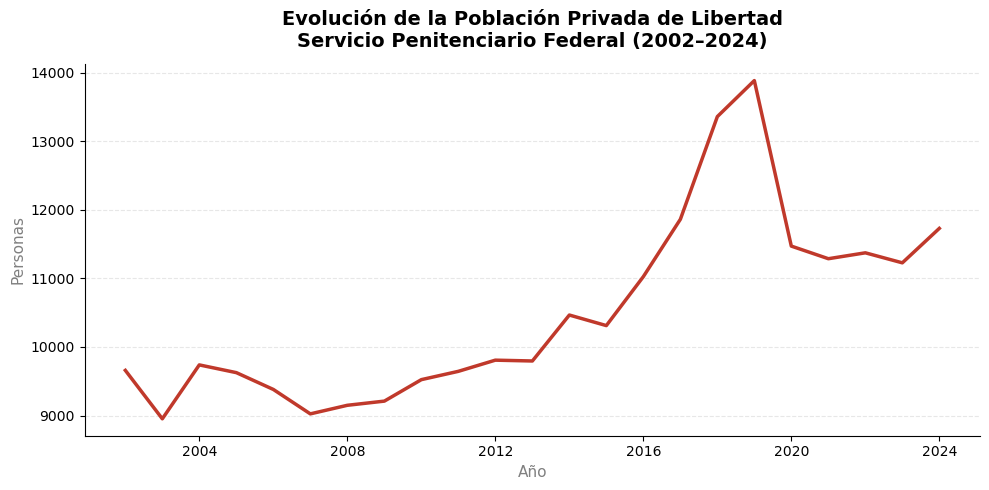

In [10]:
import matplotlib.pyplot as plt

# Gráfico estilo pyplot
plt.figure(figsize=(10, 5))

plt.plot(
    df["fecha"],
    df["poblacion_total"],
    color="#C0392B",
    linewidth=2.5
)

# Título
plt.title(
    "Evolución de la Población Privada de Libertad\nServicio Penitenciario Federal (2002–2024)",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# Etiquetas 
plt.xlabel("Año", fontsize=11, color="gray")
plt.ylabel("Personas", fontsize=11, color="gray")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("grafico_tendencia_pyplot.png", dpi=150, bbox_inches="tight")
plt.show()

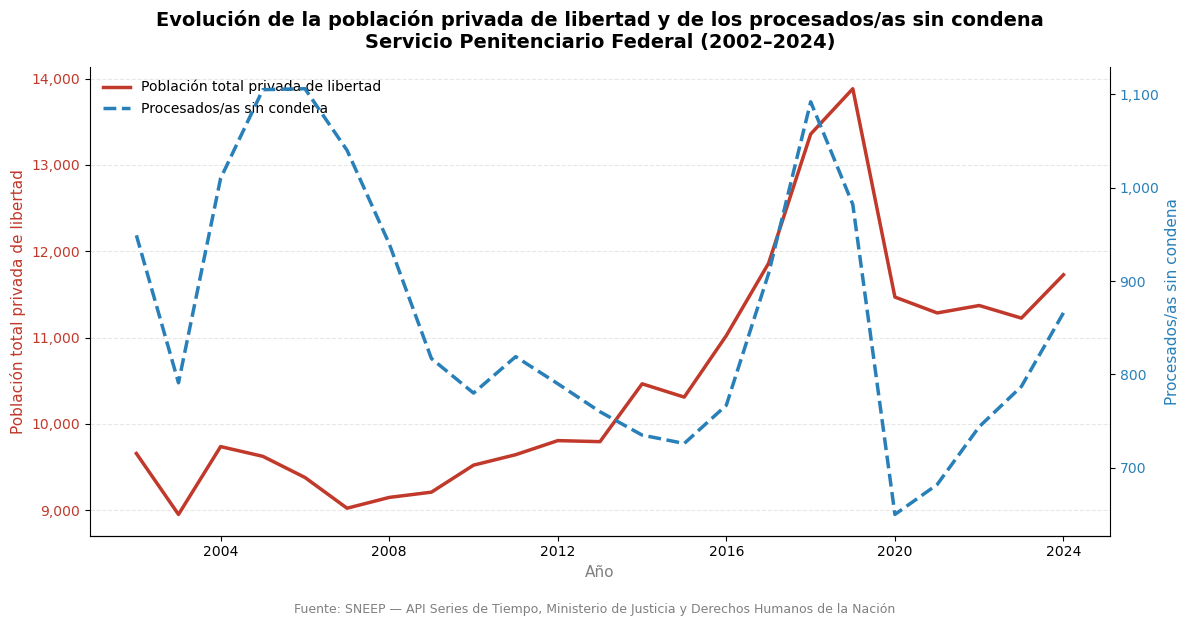

In [12]:

# Gráfico orientado a objetos
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Creamos explícitamente la figura y los ejes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Serie 1: Población total 
color1 = "#C0392B"

linea1 = ax1.plot(
    df["fecha"],
    df["poblacion_total"],
    color=color1,
    linewidth=2.5,
    label="Población total privada de libertad"
)

ax1.set_xlabel("Año", fontsize=11, color="gray")
ax1.set_ylabel("Población total privada de libertad", fontsize=11, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Formato del eje Y izquierdo con separador de miles
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# Serie 2: Procesados 
ax2 = ax1.twinx()
color2 = "#2980B9"

linea2 = ax2.plot(
    df["fecha"],
    df["procesados"],
    color=color2,
    linewidth=2.5,
    linestyle="--",
    label="Procesados/as sin condena"
)

ax2.set_ylabel("Procesados/as sin condena", fontsize=11, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Formato del eje Y derecho con separador de miles
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# Título
ax1.set_title(
    "Evolución de la población privada de libertad y de los procesados/as sin condena\n"
    "Servicio Penitenciario Federal (2002–2024)",
    fontsize=14,
    fontweight="bold",
    pad=14
)

# Leyenda combinada 
lineas = linea1 + linea2
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc="upper left", frameon=False, fontsize=10)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)

#Fuente
fig.text(
    0.5, -0.03,
    "Fuente: SNEEP — API Series de Tiempo, Ministerio de Justicia y Derechos Humanos de la Nación",
    ha="center",
    fontsize=9,
    color="gray"
)

fig.tight_layout()
fig.savefig("grafico2_orientado_objetos.png", dpi=150, bbox_inches="tight")
plt.show()

### Parte B

#### Ejercicio 4 - Documentando noticias locales y en el extranjero
Eligan dos sitios web de noticias: uno de Argentina y uno del extranjero (puede ser en castellano o en inglés como el *New York Times*).

Utilicen herramientas de webscraping para obtener los **links** de las noticias de la portada en ambos diarios. Guarden cada titular con los links obtenidos en un dataframe. Por lo tanto, debe quedarles un dataframe de 4 columnas: una columna para noticias locales, otra para su link, otra columna de noticias extranjeras y una ultima columna de sus links. Luego, expórtenlo a un archivo de excel.

En el reporte este esta parte B:
1) Inserten una captura de pantalla de la pagina del diario extranjero y en Argentina de las cuales hacen el ejercicio de extraer titulares y sus links correspondientes. Esto servirá al momento de la corrección para verificar que los links obtenidos hacen referencia a las noticias de ese día y hora.
2) Comenten brevemente (1 párrafo) las diferencias/similitudes al extraer titulares en diarios de Argentina versus diario extranjero
3) Comenten brevemente (1 párrafo) las dificultades y cómo resolvieron dichas dificultades.

*Nota*: es posible que logren obtener los links a las noticias sin el dominio: por ejemplo "https://www.lanacion.com.ar/". De ser así, concatenen el dominio a la ruta del link obtenido, tal que se obtenga un link al que se pueda acceder. Es decir, que las cadenas de caracteres finales tendrán la forma: https://www.lanacion.com.ar/*texto_obtenido*)

In [16]:
#Realizamos web scraping sobre dos diarios:

#Argentina: La Nación
#Extranjero: The Guardian (Reino Unido, en inglés)
#El objetivo es extraer los titulares de portada y sus links correspondientes.

# Importamos las librerías necesarias para web scraping

import requests
from bs4 import BeautifulSoup
import pandas as pd


In [18]:
# DIARIO ARGENTINO: La Nación (www.lanacion.com.ar)
dominio_ln = "https://www.lanacion.com.ar"
url_ln = "https://www.lanacion.com.ar/"

# Realizamos el GET request
r_ln = requests.get(url_ln)
print("Status La Nación:", r_ln.status_code)

# Parseamos el HTML con BeautifulSoup
soup_ln = BeautifulSoup(r_ln.content, "html.parser")
soup_ln

Status La Nación: 200


<!DOCTYPE html>
<html lang="es"><head><meta content="width=device-width,initial-scale=1.0,minimum-scale=0.5,maximum-scale=5.0,user-scalable=yes" name="viewport"/><link as="image" fetchpriority="high" href="https://www.lanacion.com.ar/resizer/v2/tapia-MPG6JQDS7ZF5DJYY5HPOA36IL4.jpg?auth=9f6f7a1b34b34bb10e9f48d162460fda6273a6d90732320d89980133a128ca19&amp;width=488&amp;height=325&amp;quality=70&amp;smart=true" media="(min-width: 768px)" rel="preload"/><link as="image" fetchpriority="high" href="https://www.lanacion.com.ar/resizer/v2/tapia-MPG6JQDS7ZF5DJYY5HPOA36IL4.jpg?auth=9f6f7a1b34b34bb10e9f48d162460fda6273a6d90732320d89980133a128ca19&amp;width=420&amp;height=280&amp;quality=70&amp;smart=true" media="(max-width: 767px)" rel="preload"/><link as="image" fetchpriority="high" href="https://www.lanacion.com.ar/resizer/v2/custodia-policial-frente-a-la-casa-de-manuel-RDQ3FCMTLNA55OJKJYEVSSXDIA.JPG?auth=4f78bb47d0a9f6db04e53ee694d8a0d9e18a88e168881cd15c19f6803bf92525&amp;width=302&amp;height=

In [19]:
# Extraemos titulares y links de La Nación
# Los titulares de La Nación están dentro de etiquetas <h2>
# Los links están en etiquetas <a> dentro o alrededor de los <h2>

titulares_ln = []  # lista para guardar titulares
links_ln = []      # lista para guardar links

# Buscamos todos los elementos <h2> (títulos de noticias)
h2_elements = soup_ln.find_all("h2")

for h2 in h2_elements:
    # Extraemos el texto del titular y lo limpiamos
    texto = h2.get_text(separator=" ", strip=True)
    
    # Buscamos el link asociado al titular
    # Primero buscamos un <a> dentro del <h2>
    a_tag = h2.find("a", href=True)
    
    # Si no hay <a> dentro del <h2>, buscamos el <a> padre
    if a_tag is None:
        a_tag = h2.find_parent("a", href=True)
    
    # Procesamos el link
    if a_tag and texto:  # solo guardamos si hay texto y link
        href = a_tag["href"]
        
        # Si el link es relativo (empieza con /), concatenamos el dominio
        if href.startswith("/"):
            link_completo = dominio_ln + href
        else:
            link_completo = href
        
        # Evitamos duplicados
        if texto not in titulares_ln and len(texto) > 10:
            titulares_ln.append(texto)
            links_ln.append(link_completo)

print(f"Total de titulares extraídos de La Nación: {len(titulares_ln)}")
# Mostramos los primeros 5 para verificar
for i, (t, l) in enumerate(zip(titulares_ln[:5], links_ln[:5]), 1):
    print(f"\n{i}. {t}")
    print(f"   Link: {l}")

Total de titulares extraídos de La Nación: 136

1. El juez Amarante analizó las transferencias en los meses que vencían las deudas previsionales y tributarias
   Link: https://www.lanacion.com.ar/politica/los-movimientos-millonarios-en-las-cuentas-de-la-afa-dolar-mep-transferencias-a-los-clubes-e-nid30032026/

2. 200.000 dólares. Quiénes son las dos acreedoras del préstamo con el que Adorni compró su departamento en Caballito
   Link: https://www.lanacion.com.ar/politica/quienes-son-las-dos-acreedoras-del-prestamo-con-el-que-adorni-compro-su-departamento-en-caballito-nid30032026/

3. Conmoción en Santa Fe. “¡Sorpresa!”: cómo fue el ataque a tiros y asesinato de un alumno en una escuela, según los testigos
   Link: https://www.lanacion.com.ar/seguridad/sorpresa-como-fue-el-ataque-a-tiros-y-asesinato-de-un-alumno-en-una-escuela-de-santa-fe-segun-los-nid30032026/

4. Diputados. El oficialismo confirmó a Lemoine para presidir la Comisión de Juicio Político y bloquear los intentos de remoci

In [20]:
# DIARIO EXTRANJERO: The Guardian (www.theguardian.com)
# Diario del Reino Unido, en inglés

dominio_guardian = "https://www.theguardian.com"
url_guardian = "https://www.theguardian.com/"

# GET request
r_guardian = requests.get(url_guardian)
print("Status The Guardian:", r_guardian.status_code)

# Parseamos el HTML
soup_guardian = BeautifulSoup(r_guardian.content, "html.parser")
soup_guardian

Status The Guardian: 200


<!DOCTYPE html>

<html lang="en">
<head>
<!-- Hello there, HTML enthusiast! -->
<!-- DCR commit hash 99689e8c20b5bbc72b4fee034819465bf9ce0172 -->
<title>Latest news, sport and opinion from the Guardian</title>
<meta content="Latest international news, sport and comment from the Guardian" name="description"/>
<meta charset="utf-8"/>
<link href="https://www.theguardian.com" rel="canonical"/>
<meta content="width=device-width,minimum-scale=1,initial-scale=1" name="viewport"/>
<meta content="#052962" name="theme-color">
<link href="https://assets.guim.co.uk/static/frontend/manifest.json" rel="manifest"/>
<link href="https://assets.guim.co.uk/static/frontend/icons/homescreen/apple-touch-icon.svg" rel="apple-touch-icon" sizes="any"/>
<link href="https://assets.guim.co.uk/static/frontend/icons/homescreen/apple-touch-icon-512.png" rel="apple-touch-icon" sizes="512x512"/>
<link href="https://assets.guim.co.uk/static/frontend/icons/homescreen/apple-touch-icon-360.png" rel="apple-touch-icon" size

In [21]:
# Extraemos titulares y links de The Guardian
# The Guardian estructura sus titulares en etiquetas <a> con
# clases específicas. Buscamos los <a> que contienen los títulos
# usando el atributo data-link-name o buscando los h3 con links


titulares_guardian = []
links_guardian = []

# En The Guardian los titulares de portada se encuentran
# principalmente en etiquetas <h3> dentro de los articles
h3_elements = soup_guardian.find_all(["h3", "h2"])

for h_tag in h3_elements:
    texto = h_tag.get_text(separator=" ", strip=True)
    
    # Buscamos el <a> dentro del heading o en el padre
    a_tag = h_tag.find("a", href=True)
    if a_tag is None:
        a_tag = h_tag.find_parent("a", href=True)
    
    if a_tag and texto and len(texto) > 10:
        href = a_tag["href"]
        
        # Concatenamos dominio si el link es relativo
        if href.startswith("/"):
            link_completo = dominio_guardian + href
        else:
            link_completo = href
        
        # Filtramos solo links del dominio de The Guardian
        if "theguardian.com" in link_completo and texto not in titulares_guardian:
            titulares_guardian.append(texto)
            links_guardian.append(link_completo)

print(f"Total de titulares extraídos de The Guardian: {len(titulares_guardian)}")
for i, (t, l) in enumerate(zip(titulares_guardian[:5], links_guardian[:5]), 1):
    print(f"\n{i}. {t}")
    print(f"   Link: {l}")

Total de titulares extraídos de The Guardian: 23

1. Middle East crisis
   Link: https://www.theguardian.com/world/us-israel-war-on-iran

2. US-Israel war on Iran Trump threatens to ‘obliterate’ Iran’s energy grid if ceasefire not reached ‘shortly’
   Link: https://www.theguardian.com/us-news/2026/mar/30/trump-threatens-to-obliterate-irans-energy-grid-if-ceasefire-not-reached-shortly

3. Business IMF warns Middle East conflict will lead to higher prices and slower global growth
   Link: https://www.theguardian.com/world/2026/mar/30/imf-warns-middle-east-conflict-will-lead-to-higher-prices-and-slower-global-growth

4. Spain Spain closes airspace to US military over Iran war, widening rift with US
   Link: https://www.theguardian.com/world/2026/mar/30/spain-closes-airspace-to-us-military-over-iran-war-widening-rift-with-us

5. US How could US forcibly reopen strait of Hormuz and what are the risks?
   Link: https://www.theguardian.com/world/2026/mar/30/how-could-us-forcibly-reopen-strait

In [22]:
# ARMADO DEL DATAFRAME FINAL con las 4 columnas requeridas:

n = min(len(titulares_ln), len(titulares_guardian))
print(f"Usando {n} titulares de cada diario")

df_noticias = pd.DataFrame({
    "Titular_LaNacion": titulares_ln[:n],
    "Link_LaNacion": links_ln[:n],
    "Titular_TheGuardian": titulares_guardian[:n],
    "Link_TheGuardian": links_guardian[:n]
})

print(f"\nDataFrame final: {df_noticias.shape[0]} filas x {df_noticias.shape[1]} columnas")
print("\nPrimeras filas:")
df_noticias.head()

Usando 23 titulares de cada diario

DataFrame final: 23 filas x 4 columnas

Primeras filas:


,Titular_LaNacion,Link_LaNacion,Titular_TheGuardian,Link_TheGuardian
0,El juez Amarante analizó las transferencias en...,https://www.lanacion.com.ar/politica/los-movim...,Middle East crisis,https://www.theguardian.com/world/us-israel-wa...
1,200.000 dólares. Quiénes son las dos acreedora...,https://www.lanacion.com.ar/politica/quienes-s...,US-Israel war on Iran Trump threatens to ‘obli...,https://www.theguardian.com/us-news/2026/mar/3...
2,Conmoción en Santa Fe. “¡Sorpresa!”: cómo fue ...,https://www.lanacion.com.ar/seguridad/sorpresa...,Business IMF warns Middle East conflict will l...,https://www.theguardian.com/world/2026/mar/30/...
3,Diputados. El oficialismo confirmó a Lemoine p...,https://www.lanacion.com.ar/politica/el-oficia...,Spain Spain closes airspace to US military ove...,https://www.theguardian.com/world/2026/mar/30/...
4,Horror en Santa Fe. Todo lo que se sabe del al...,https://www.lanacion.com.ar/sociedad/horror-en...,US How could US forcibly reopen strait of Horm...,https://www.theguardian.com/world/2026/mar/30/...


In [23]:
# EXPORTAMOS A EXCEL
# Guardamos el DataFrame como archivo .xlsx

nombre_archivo = "noticias_portada_TP1.xlsx"

# Exportamos a Excel
df_noticias.to_excel(nombre_archivo, index=False, sheet_name="Portadas")

print(f"✓ Archivo exportado exitosamente: {nombre_archivo}")
print(f"  Filas: {df_noticias.shape[0]}")
print(f"  Columnas: {list(df_noticias.columns)}")

✓ Archivo exportado exitosamente: noticias_portada_TP1.xlsx
  Filas: 23
  Columnas: ['Titular_LaNacion', 'Link_LaNacion', 'Titular_TheGuardian', 'Link_TheGuardian']
